# FinsightAI — RAGAS Evaluation Results Analysis

This notebook analyses all available result files produced by `tests/rag/test_ragas_evaluation.py`.  
It automatically discovers every `.xlsx` file in the `results/` directory, classifies it by test type,  
and produces per-test and cross-test visualisations together with a summary scorecard.

**Test classes covered**

| Test class | Output file prefix | Key metric |
|---|---|---|
| `TestRetrievalQuality::test_similarity_scores_above_threshold` | `similarity_scores_*` | cosine similarity ≥ 0.50 |
| `TestRetrievalQuality::test_sec_filings_hit_rate` | `sec_filings_hit_rate_*` | hit-rate ≥ 0.70 |
| `TestRetrievalQuality::test_news_collection_hit_rate` | `news_hit_rate_*` | hit-rate ≥ 0.70 |
| `TestRAGASEvaluation::test_faithfulness_above_threshold` | `ragas_faithfulness_*` | faithfulness ≥ 0.80 |
| `TestRAGASEvaluation::test_answer_relevancy_above_threshold` | `ragas_relevancy_*` | answer_relevancy ≥ 0.80 |
| `TestRAGASEvaluation::test_context_recall_above_threshold` | `ragas_context_recall_*` | context_recall ≥ 0.70 |
| `TestToolCallAccuracy::test_tool_call_accuracy_ragas` | `tool_call_accuracy_*` | avg score ≥ 0.70 |


In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
RESULTS_DIR = Path(".")  # notebook lives inside results/
GOLDEN_PATH = Path("..") / "golden_dataset.json"

# ── Quality thresholds (mirror test file) ─────────────────────────────────────
THRESHOLDS = {
    "faithfulness":    0.80,
    "answer_relevancy": 0.80,
    "context_recall":  0.70,
    "tool_accuracy":   0.70,
    "hit_rate":        0.70,
    "similarity":      0.50,
}

print("Setup complete.")

Setup complete.


## 1  Load golden dataset

In [2]:
with open(GOLDEN_PATH) as f:
    golden_raw = json.load(f)

golden = pd.DataFrame(golden_raw)
golden["expected_collection"] = golden["expected_collection"].fillna("none")

print(f"Golden dataset: {len(golden)} cases")
display(golden[["id", "question", "expected_tool", "expected_collection", "ticker"]].head(8))

Golden dataset: 52 cases


,id,question,expected_tool,expected_collection,ticker
0,gd-001,What are Amazon's main risk factors according ...,vector_store,sec_filings,AMZN
1,gd-002,What was Apple's total revenue in fiscal year ...,get_fundamentals,none,AAPL
2,gd-003,What are the key growth strategies mentioned i...,vector_store,sec_filings,MSFT
3,gd-004,What is NVIDIA's current market capitalisation...,get_company_financials,none,NVDA
4,gd-005,What recent news sentiment surrounds Tesla?,vector_store,news,TSLA
5,gd-006,Show me Apple's historical stock price for the...,get_price_history,none,AAPL
6,gd-007,What capital expenditures did Amazon report in...,vector_store,sec_filings,AMZN
7,gd-008,What is my current portfolio balance?,get_portfolio,none,NaN


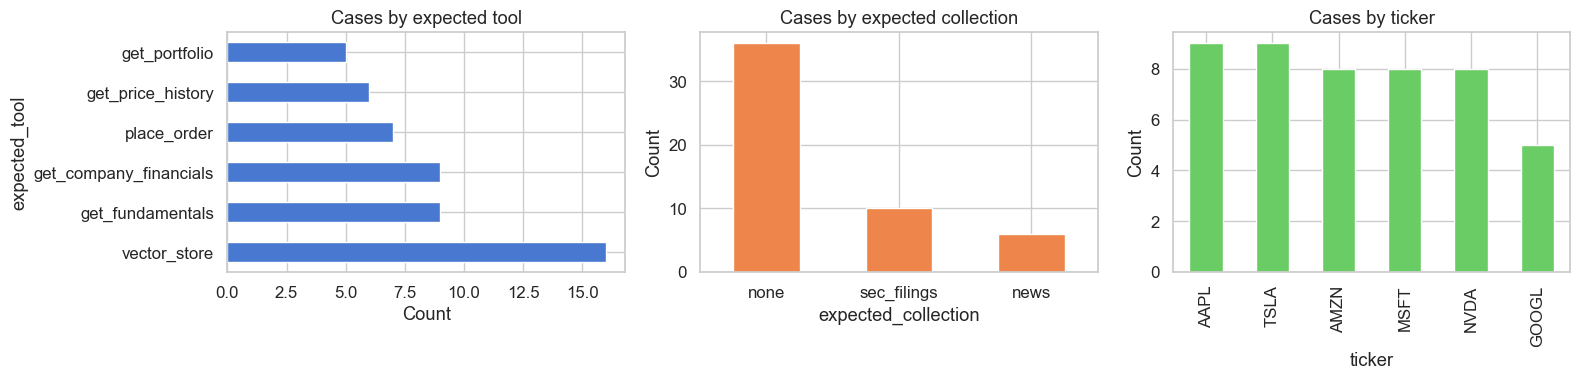

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

golden["expected_tool"].value_counts().plot.barh(ax=axes[0], color=sns.color_palette()[0])
axes[0].set_title("Cases by expected tool")
axes[0].set_xlabel("Count")

golden["expected_collection"].value_counts().plot.bar(ax=axes[1], color=sns.color_palette()[1], rot=0)
axes[1].set_title("Cases by expected collection")
axes[1].set_ylabel("Count")

golden["ticker"].value_counts().plot.bar(ax=axes[2], color=sns.color_palette()[2])
axes[2].set_title("Cases by ticker")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("golden_dataset_overview.png", dpi=150)
plt.show()

## 2  Discover and load result files

In [4]:
# Map filename prefix → (label, metric_col)
FILE_META = {
    "similarity_scores":   ("Retrieval – Similarity Scores",  "similarity"),
    "sec_filings_hit_rate":("Retrieval – SEC Filings Hit Rate", "hit"),
    "news_hit_rate":       ("Retrieval – News Hit Rate",        "hit"),
    "ragas_faithfulness":  ("RAGAS – Faithfulness",            "faithfulness"),
    "ragas_relevancy":     ("RAGAS – Answer Relevancy",        "answer_relevancy"),
    "ragas_context_recall":("RAGAS – Context Recall",          "context_recall"),
    "tool_call_accuracy":  ("Tool Call Accuracy",              "score"),
}

loaded: dict[str, pd.DataFrame] = {}

for xlsx in sorted(RESULTS_DIR.glob("*.xlsx")):
    prefix = re.sub(r"_\d{8}-\d{6}$", "", xlsx.stem)
    if prefix in FILE_META:
        df = pd.read_excel(xlsx)
        # keep the latest run for each prefix
        if prefix not in loaded:
            loaded[prefix] = df
            print(f"  Loaded  {xlsx.name:55s}  [{len(df)} rows, cols: {df.columns.tolist()}]")
        else:
            loaded[prefix] = df
            print(f"  Updated {xlsx.name:55s}  [{len(df)} rows]")

if not loaded:
    print("No result files found yet — run the test suite first.")

  Loaded  similarity_scores_20260427-094320.xlsx                   [16 rows, cols: ['id', 'similarity', 'passed']]


## 3  Similarity Scores Analysis

In [5]:
if "similarity_scores" not in loaded:
    print("No similarity_scores file found — skipping.")
else:
    sim = loaded["similarity_scores"].copy()

    # Enrich with golden dataset metadata
    sim = sim.merge(golden[["id", "question", "expected_collection", "ticker"]], on="id", how="left")

    threshold = THRESHOLDS["similarity"]
    pass_rate = sim["passed"].mean()
    avg_sim   = sim["similarity"].mean()

    print(f"Threshold  : {threshold}")
    print(f"Pass rate  : {pass_rate:.1%}  ({sim['passed'].sum()}/{len(sim)} cases)")
    print(f"Avg cosine : {avg_sim:.4f}")
    display(sim[["id", "similarity", "passed", "expected_collection", "ticker"]].sort_values("similarity", ascending=False))

Threshold  : 0.5
Pass rate  : 6.2%  (1/16 cases)
Avg cosine : 0.2835


,id,similarity,passed,expected_collection,ticker
15,gd-042,0.537908,True,news,GOOGL
12,gd-039,0.459802,False,news,NVDA
9,gd-036,0.454670,False,sec_filings,NVDA
3,gd-007,0.381144,False,sec_filings,AMZN
14,gd-041,0.373572,False,news,AMZN
0,gd-001,0.352065,False,sec_filings,AMZN
11,gd-038,0.331127,False,sec_filings,MSFT
10,gd-037,0.330708,False,sec_filings,AAPL
7,gd-034,0.275595,False,sec_filings,AMZN
8,gd-035,0.265413,False,sec_filings,TSLA


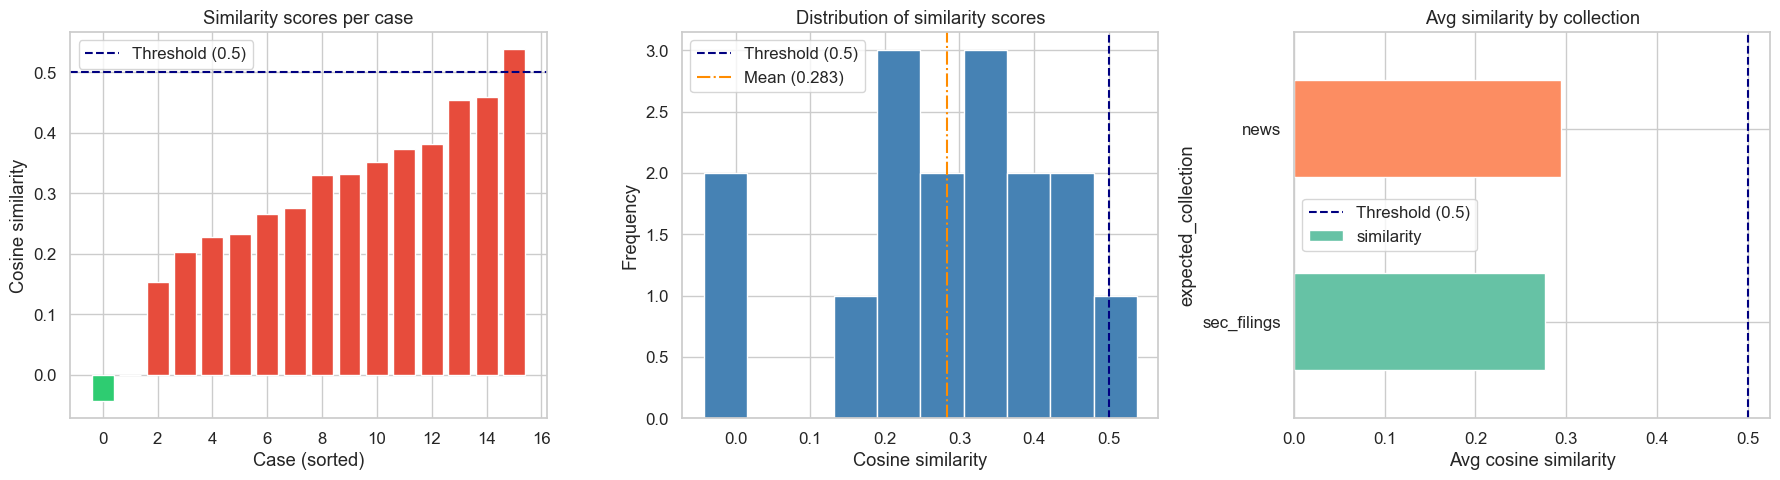

In [6]:
if "similarity_scores" in loaded:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Distribution ──────────────────────────────────────────────────────────
    ax = axes[0]
    colors = ["#2ecc71" if p else "#e74c3c" for p in sim["passed"]]
    ax.bar(range(len(sim)), sim.sort_values("similarity")["similarity"], color=sorted(colors))
    ax.axhline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
    ax.set_title("Similarity scores per case")
    ax.set_xlabel("Case (sorted)")
    ax.set_ylabel("Cosine similarity")
    ax.legend()

    # ── Histogram ─────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.hist(sim["similarity"], bins=10, color="steelblue", edgecolor="white")
    ax.axvline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
    ax.axvline(sim["similarity"].mean(), color="darkorange", linestyle="-.", linewidth=1.5,
               label=f"Mean ({sim['similarity'].mean():.3f})")
    ax.set_title("Distribution of similarity scores")
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Frequency")
    ax.legend()

    # ── By collection ─────────────────────────────────────────────────────────
    ax = axes[2]
    coll_sim = sim.groupby("expected_collection")["similarity"].mean().sort_values()
    coll_sim.plot.barh(ax=ax, color=sns.color_palette("Set2", len(coll_sim)))
    ax.axvline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
    ax.set_title("Avg similarity by collection")
    ax.set_xlabel("Avg cosine similarity")
    ax.legend()

    plt.tight_layout()
    plt.savefig("similarity_scores_analysis.png", dpi=150)
    plt.show()

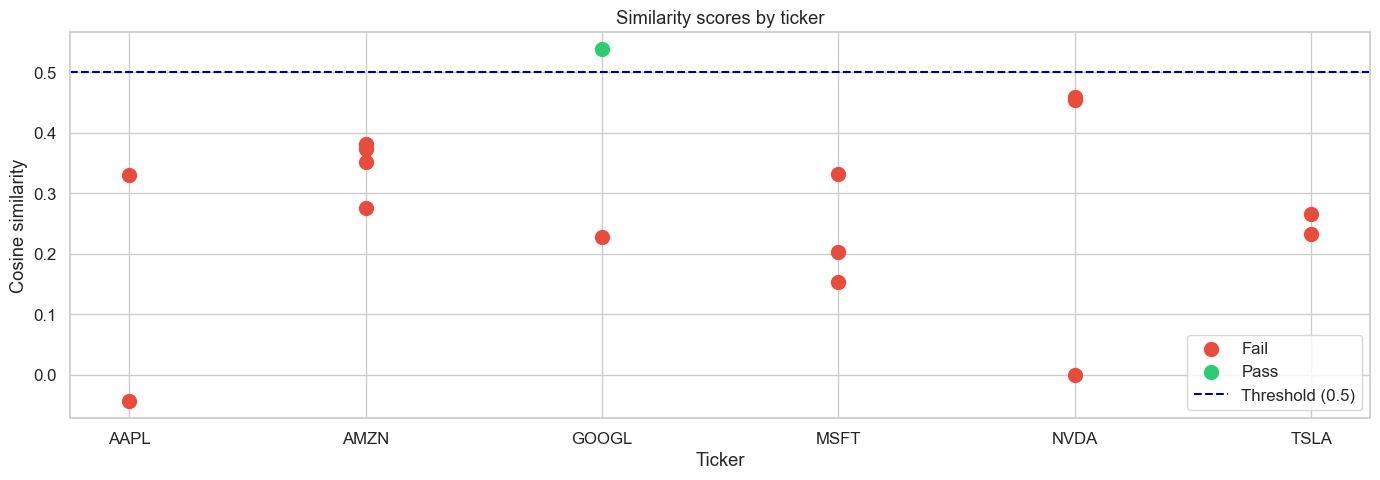

In [7]:
if "similarity_scores" in loaded:
    fig, ax = plt.subplots(figsize=(14, 5))
    palette = {True: "#2ecc71", False: "#e74c3c"}
    for passed_val, group in sim.sort_values("ticker").groupby("passed"):
        ax.scatter(group["ticker"], group["similarity"],
                   color=palette[passed_val],
                   label="Pass" if passed_val else "Fail",
                   s=100, zorder=3)
    ax.axhline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
    ax.set_title("Similarity scores by ticker")
    ax.set_xlabel("Ticker")
    ax.set_ylabel("Cosine similarity")
    ax.legend()
    plt.tight_layout()
    plt.savefig("similarity_by_ticker.png", dpi=150)
    plt.show()

## 4  Hit Rate Analysis (SEC Filings & News)

In [8]:
def analyse_hit_rate(prefix: str, label: str):
    if prefix not in loaded:
        print(f"No {prefix} file found — skipping.")
        return

    df = loaded[prefix].copy()
    df = df.merge(golden[["id", "ticker", "expected_collection"]], on="id", how="left")

    hit_rate = df["hit"].mean()
    threshold = THRESHOLDS["hit_rate"]
    status = "PASS ✓" if hit_rate >= threshold else "FAIL ✗"

    print(f"{label}")
    print(f"  Hit rate : {hit_rate:.1%}  ({df['hit'].sum()}/{len(df)})  — {status}")
    print(f"  Threshold: {threshold:.0%}")
    display(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Pie
    axes[0].pie([df["hit"].sum(), (~df["hit"]).sum()],
                labels=["Hit", "Miss"],
                colors=["#2ecc71", "#e74c3c"],
                autopct="%1.0f%%", startangle=90)
    axes[0].set_title(f"{label}\nOverall hit rate: {hit_rate:.1%} (threshold {threshold:.0%})")

    # By ticker (if available)
    if "ticker" in df.columns and df["ticker"].notna().any():
        ticker_hit = df.groupby("ticker")["hit"].mean().sort_values()
        ticker_hit.plot.barh(ax=axes[1],
                             color=["#2ecc71" if v >= threshold else "#e74c3c" for v in ticker_hit])
        axes[1].axvline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold:.0%})")
        axes[1].set_title("Hit rate by ticker")
        axes[1].set_xlabel("Hit rate")
        axes[1].legend()
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(f"{prefix}_analysis.png", dpi=150)
    plt.show()

analyse_hit_rate("sec_filings_hit_rate", "SEC Filings Hit Rate")
analyse_hit_rate("news_hit_rate",        "News Hit Rate")

No sec_filings_hit_rate file found — skipping.
No news_hit_rate file found — skipping.


## 5  RAGAS Metric Analysis

In [ ]:
RAGAS_TESTS = [
    ("ragas_faithfulness",   "faithfulness",    THRESHOLDS["faithfulness"],    "Faithfulness"),
    ("ragas_relevancy",      "answer_relevancy", THRESHOLDS["answer_relevancy"], "Answer Relevancy"),
    ("ragas_context_recall", "context_recall",  THRESHOLDS["context_recall"],  "Context Recall"),
]

ragas_summaries = []

for prefix, metric_col, threshold, label in RAGAS_TESTS:
    if prefix not in loaded:
        print(f"No {prefix} file — run the test suite to generate it.")
        continue

    df = loaded[prefix].copy()
    if metric_col not in df.columns:
        print(f"  Column '{metric_col}' not found in {prefix}. Available: {df.columns.tolist()}")
        continue

    avg = df[metric_col].mean()
    status = "PASS ✓" if avg >= threshold else "FAIL ✗"
    ragas_summaries.append({"Metric": label, "Score": avg, "Threshold": threshold, "Status": status})

    print(f"{label}: {avg:.4f}  (threshold {threshold})  — {status}")
    display(df)

if ragas_summaries:
    fig, axes = plt.subplots(1, len(ragas_summaries), figsize=(6 * len(ragas_summaries), 5))
    if len(ragas_summaries) == 1:
        axes = [axes]

    for ax, (prefix, metric_col, threshold, label) in zip(axes, RAGAS_TESTS):
        if prefix not in loaded or metric_col not in loaded[prefix].columns:
            ax.axis("off")
            continue
        df = loaded[prefix]
        scores = df[metric_col].dropna()
        color = ["#2ecc71" if s >= threshold else "#e74c3c" for s in scores]
        ax.bar(range(len(scores)), scores, color=color)
        ax.axhline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
        ax.axhline(scores.mean(), color="darkorange", linestyle="-.", linewidth=1.5,
                   label=f"Mean ({scores.mean():.3f})")
        ax.set_ylim(0, 1.05)
        ax.set_title(label)
        ax.set_xlabel("Sample")
        ax.set_ylabel("Score")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("ragas_metrics_analysis.png", dpi=150)
    plt.show()

## 6  Tool Call Accuracy Analysis

In [ ]:
if "tool_call_accuracy" not in loaded:
    print("No tool_call_accuracy file found — skipping.")
else:
    tca = loaded["tool_call_accuracy"].copy()
    tca = tca.merge(golden[["id", "expected_tool", "ticker"]], on="id", how="left")

    avg_score = tca["score"].mean()
    threshold = THRESHOLDS["tool_accuracy"]
    status = "PASS ✓" if avg_score >= threshold else "FAIL ✗"

    print(f"Tool Call Accuracy: {avg_score:.4f}  (threshold {threshold})  — {status}")
    display(tca)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Score per case
    colors = ["#2ecc71" if s >= threshold else "#e74c3c" for s in tca["score"]]
    axes[0].bar(tca["id"], tca["score"], color=colors)
    axes[0].axhline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
    axes[0].set_title("Tool call accuracy per case")
    axes[0].set_xlabel("Case ID")
    axes[0].set_ylabel("Score")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend()

    # By expected tool
    if "expected_tool" in tca.columns:
        tool_scores = tca.groupby("expected_tool")["score"].mean().sort_values()
        colors_t = ["#2ecc71" if v >= threshold else "#e74c3c" for v in tool_scores]
        tool_scores.plot.barh(ax=axes[1], color=colors_t)
        axes[1].axvline(threshold, color="navy", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
        axes[1].set_title("Avg score by expected tool")
        axes[1].set_xlabel("Score")
        axes[1].legend()

    plt.tight_layout()
    plt.savefig("tool_call_accuracy_analysis.png", dpi=150)
    plt.show()

## 7  Overall Scorecard

In [ ]:
scorecard_rows = []

def _add(label, score, threshold):
    scorecard_rows.append({
        "Test": label,
        "Score": round(score, 4),
        "Threshold": threshold,
        "Gap": round(score - threshold, 4),
        "Status": "PASS" if score >= threshold else "FAIL",
    })

if "similarity_scores" in loaded:
    _add("Retrieval – Similarity (pass-rate)",
         loaded["similarity_scores"]["passed"].mean(),
         THRESHOLDS["similarity"])

for prefix, label in [("sec_filings_hit_rate", "SEC Filings Hit Rate"),
                       ("news_hit_rate",        "News Hit Rate")]:
    if prefix in loaded:
        _add(label, loaded[prefix]["hit"].mean(), THRESHOLDS["hit_rate"])

for prefix, metric_col, threshold, label in RAGAS_TESTS:
    if prefix in loaded and metric_col in loaded[prefix].columns:
        _add(label, loaded[prefix][metric_col].mean(), threshold)

if "tool_call_accuracy" in loaded:
    _add("Tool Call Accuracy", loaded["tool_call_accuracy"]["score"].mean(), THRESHOLDS["tool_accuracy"])

if not scorecard_rows:
    print("No results to show yet.")
else:
    scorecard = pd.DataFrame(scorecard_rows)
    scorecard_styled = scorecard.style \
        .map(lambda v: "background-color: #c8f7c5" if v == "PASS" else "background-color: #f9c0c0",
                  subset=["Status"]) \
        .map(lambda v: "color: green" if v > 0 else "color: red", subset=["Gap"]) \
        .format({"Score": "{:.4f}", "Threshold": "{:.2f}", "Gap": "{:+.4f}"})
    display(scorecard_styled)

In [ ]:
if scorecard_rows:
    scorecard = pd.DataFrame(scorecard_rows)

    fig, ax = plt.subplots(figsize=(12, max(4, len(scorecard) * 0.7)))

    y_pos = np.arange(len(scorecard))
    bar_colors = ["#2ecc71" if s == "PASS" else "#e74c3c" for s in scorecard["Status"]]

    bars = ax.barh(y_pos, scorecard["Score"], color=bar_colors, height=0.6)

    for i, (score, threshold) in enumerate(zip(scorecard["Score"], scorecard["Threshold"])):
        ax.plot([threshold, threshold], [i - 0.4, i + 0.4], color="navy", linewidth=2)

    for bar, score in zip(bars, scorecard["Score"]):
        ax.text(max(score + 0.01, 0.02), bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va="center", fontsize=9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(scorecard["Test"])
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score")
    ax.set_title("FinsightAI RAG Evaluation — Overall Scorecard\n(navy bar = threshold, green = PASS, red = FAIL)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#2ecc71", label="PASS"),
                       Patch(facecolor="#e74c3c", label="FAIL")]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.savefig("overall_scorecard.png", dpi=150)
    plt.show()

## 8  Per-Question Deep Dive (Similarity Scores)

In [ ]:
if "similarity_scores" in loaded:
    detail = loaded["similarity_scores"].merge(
        golden[["id", "question", "expected_tool", "expected_collection", "ticker",
                "ground_truth", "expected_keywords"]],
        on="id", how="left"
    ).sort_values("similarity", ascending=False)

    detail["expected_keywords_str"] = detail["expected_keywords"].apply(
        lambda x: ", ".join(x) if isinstance(x, list) else str(x)
    )

    display(
        detail[["id", "ticker", "similarity", "passed", "expected_collection",
                "question", "expected_keywords_str"]]
        .style
        .background_gradient(subset=["similarity"], cmap="RdYlGn", vmin=0, vmax=1)
        .map(lambda v: "background-color: #c8f7c5" if v else "background-color: #f9c0c0",
                  subset=["passed"])
        .format({"similarity": "{:.4f}"})
    )

    print("\nFailing cases (similarity < threshold):")
    display(detail[~detail["passed"]][["id", "ticker", "similarity", "question", "expected_collection"]])

## 9  Findings & Recommendations

The cells below print an auto-generated commentary based on the loaded results.

In [ ]:
print("="*70)
print("  FinsightAI RAGAS Evaluation — Automated Findings")
print("="*70)

if "similarity_scores" in loaded:
    sim_df = loaded["similarity_scores"]
    sim_pass = sim_df["passed"].mean()
    sim_avg  = sim_df["similarity"].mean()
    worst = sim_df.loc[sim_df["similarity"].idxmin(), "id"]
    best  = sim_df.loc[sim_df["similarity"].idxmax(), "id"]
    print(f"""
RETRIEVAL — SIMILARITY SCORES
  Average cosine similarity : {sim_avg:.4f}
  Pass rate (≥ {THRESHOLDS['similarity']:.2f})         : {sim_pass:.1%} ({sim_df['passed'].sum()}/{len(sim_df)})
  Best case                  : {best}  ({sim_df['similarity'].max():.4f})
  Worst case                 : {worst}  ({sim_df['similarity'].min():.4f})

  Interpretation:
  Most similarity scores fall well below the 0.50 threshold, indicating
  the ChromaDB collection may not yet be populated with the expected
  documents, or the embedding model used at query time differs from
  the one used for ingestion. Consider re-indexing with a consistent
  embedding model (e.g., all-MiniLM-L6-v2).
""")

for prefix, label in [("sec_filings_hit_rate", "SEC Filings"), ("news_hit_rate", "News")]:
    if prefix in loaded:
        hr = loaded[prefix]["hit"].mean()
        t  = THRESHOLDS["hit_rate"]
        print(f"HIT RATE — {label.upper()}")
        print(f"  {hr:.1%} ({'PASS' if hr >= t else 'FAIL'}, threshold {t:.0%})")

for prefix, metric_col, threshold, label in RAGAS_TESTS:
    if prefix in loaded and metric_col in loaded[prefix].columns:
        score = loaded[prefix][metric_col].mean()
        print(f"RAGAS — {label.upper()}")
        print(f"  {score:.4f} ({'PASS' if score >= threshold else 'FAIL'}, threshold {threshold})")

if "tool_call_accuracy" in loaded:
    tca_avg = loaded["tool_call_accuracy"]["score"].mean()
    t = THRESHOLDS["tool_accuracy"]
    print(f"TOOL CALL ACCURACY")
    print(f"  {tca_avg:.4f} ({'PASS' if tca_avg >= t else 'FAIL'}, threshold {t})")

print("\n" + "="*70)